In [13]:
import gymnasium as gym
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from assignment2_utils import describe_env, simulate_episodes, main
from taxi_agent import Agent

## Plots

Observation space:  Discrete(500)
Observation space size:  500
Reward Range:  (-inf, inf)
Number of actions:  6
Action description:  {0: 'Move south (down)', 1: 'Move north (up)', 2: 'Move east (right)', 3: 'Move west (left)', 4: 'Pickup passenger', 5: 'Drop off passenger'}


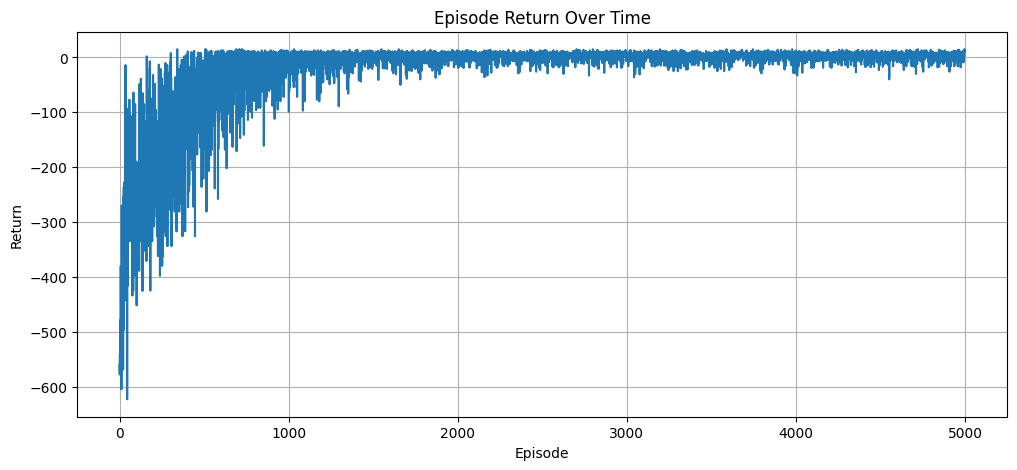

In [14]:
env = gym.make("Taxi-v3")
num_states, num_actions = describe_env(env)

agent = Agent(num_states, num_actions, alpha=0.1, epsilon=0.1, gamma=0.9)
returns, steps = agent.train(env, num_episodes=5000)

plt.figure(figsize=(12,5))
plt.plot(returns)
plt.title("Episode Return Over Time")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.grid(True)
plt.show()

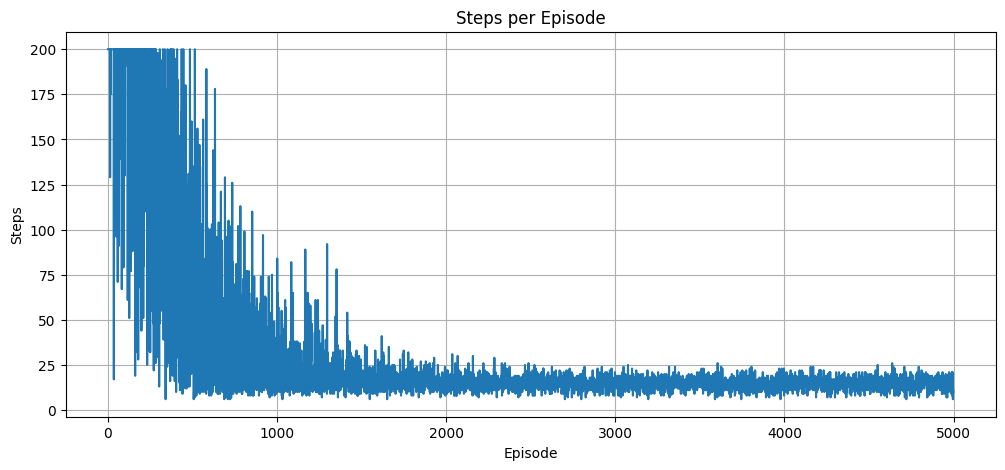

In [15]:
plt.figure(figsize=(12,5))
plt.plot(steps)
plt.title("Steps per Episode")
plt.xlabel("Episode")
plt.ylabel("Steps")
plt.grid(True)
plt.show()

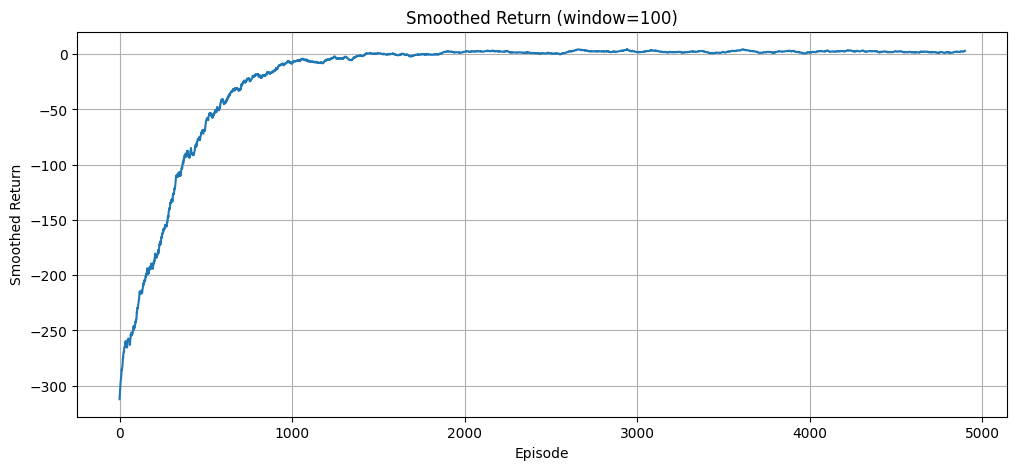

In [16]:
window = 100
smoothed = np.convolve(returns, np.ones(window)/window, mode='valid')

plt.figure(figsize=(12,5))
plt.plot(smoothed)
plt.title(f"Smoothed Return (window={window})")
plt.xlabel("Episode")
plt.ylabel("Smoothed Return")
plt.grid(True)
plt.show()

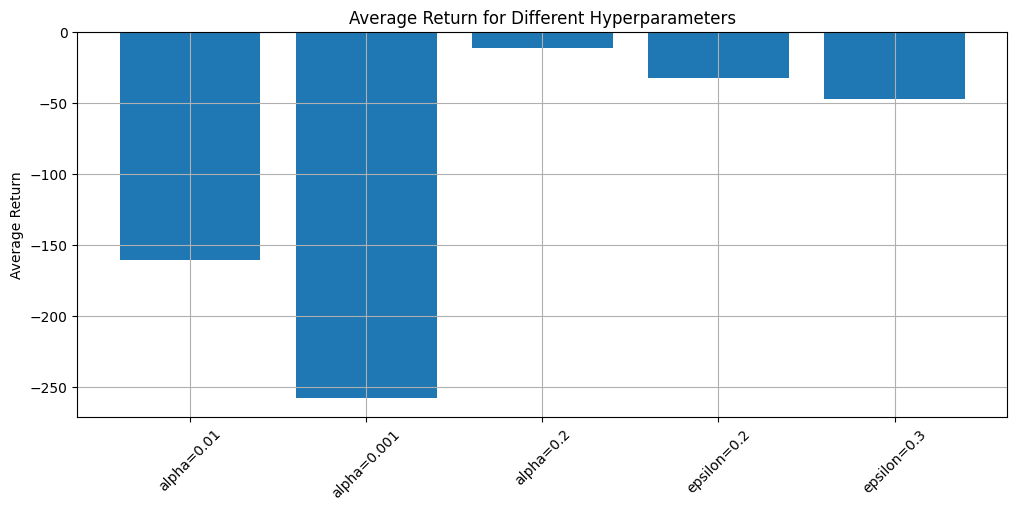

In [17]:
results = {}

alphas = [0.01, 0.001, 0.2]

for a in alphas:
    agent = Agent(num_states, num_actions, alpha=a, epsilon=0.1, gamma=0.9)
    returns, steps = agent.train(env, num_episodes=5000)

    # Store results in the dictionary
    results[f"alpha={a}"] = {
        "returns": returns,
        "steps": steps
    }

epsilons = [0.2, 0.3]

for e in epsilons:
    agent = Agent(num_states, num_actions, alpha=0.1, epsilon=e, gamma=0.9)
    returns, steps = agent.train(env, num_episodes=5000)

    results[f"epsilon={e}"] = {
        "returns": returns,
        "steps": steps
    }

labels = []
avg_returns = []

# Bar chart comparing average returns
for key, metrics in results.items():
    labels.append(key)
    avg_returns.append(np.mean(metrics["returns"]))

plt.figure(figsize=(12,5))
plt.bar(labels, avg_returns)
plt.title("Average Return for Different Hyperparameters")
plt.ylabel("Average Return")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [18]:
print(results)

{'alpha=0.01': {'returns': [-560, -264, -533, -389, -533, -587, -263, -560, -398, -524, -434, -542, -488, -371, -308, -335, -560, -245, -452, -263, -425, -281, -236, -317, -515, -560, -245, -398, -236, -425, -245, -299, -587, -227, -533, -425, -245, -407, -452, -254, -195, -425, -254, -398, -245, -94, -227, -335, -331, -245, -308, -263, -290, -335, -263, -272, -245, -281, -254, -281, -227, -236, -79, -317, -110, -344, -389, -147, -317, -245, -317, -290, -227, -290, -263, -326, -263, -236, -19, -15, -434, -147, -335, -299, -272, -299, -263, -281, -434, -344, -353, -461, -290, -353, -227, -344, -254, -236, -162, -263, -371, -254, -335, -308, -245, -254, -254, -281, -290, -226, -308, -227, -254, -123, -290, -326, -263, -263, -398, -344, -263, -254, -58, -137, -254, -281, -290, -290, -299, -254, -353, -299, -317, -290, -190, -263, -317, -317, -272, -362, -308, -254, -335, -158, -245, -227, -254, -335, -187, -245, -245, -245, -254, -299, -290, -299, -344, -317, -308, -272, -281, -263, -272,

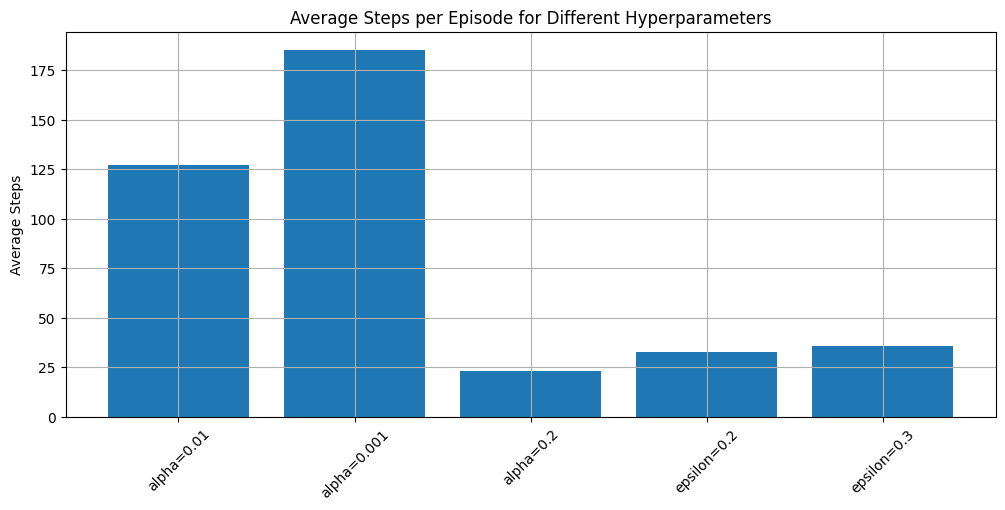

In [19]:
labels = []
avg_steps = []

for key, metrics in results.items():
    labels.append(key)
    avg_steps.append(np.mean(metrics["steps"]))

# Bar chart comparing average steps
plt.figure(figsize=(12,5))
plt.bar(labels, avg_steps)
plt.title("Average Steps per Episode for Different Hyperparameters")
plt.ylabel("Average Steps")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [20]:
for key, metrics in results.items():
    print(key, "avg return:", np.mean(metrics["returns"]))

alpha=0.01 avg return: -160.6058
alpha=0.001 avg return: -258.0934
alpha=0.2 avg return: -11.2332
epsilon=0.2 avg return: -32.4382
epsilon=0.3 avg return: -47.184


In [21]:
for key, metrics in results.items():
    print(key, "avg steps:", np.mean(metrics["steps"]))

alpha=0.01 avg steps: 127.2452
alpha=0.001 avg steps: 184.993
alpha=0.2 avg steps: 23.2524
epsilon=0.2 avg steps: 32.6548
epsilon=0.3 avg steps: 35.9568


In [ ]:
window = 100

plt.figure(figsize=(12,6))
for key, metrics in results.items():
    smoothed = np.convolve(metrics["returns"], np.ones(window)/window, mode='valid')
    plt.plot(smoothed, label=key)

plt.title("Smoothed Returns for Hyperparameter Comparison")
plt.xlabel("Episode")
plt.ylabel("Smoothed Return")
plt.legend()
plt.grid(True)
plt.show()

# Q-table heatmap

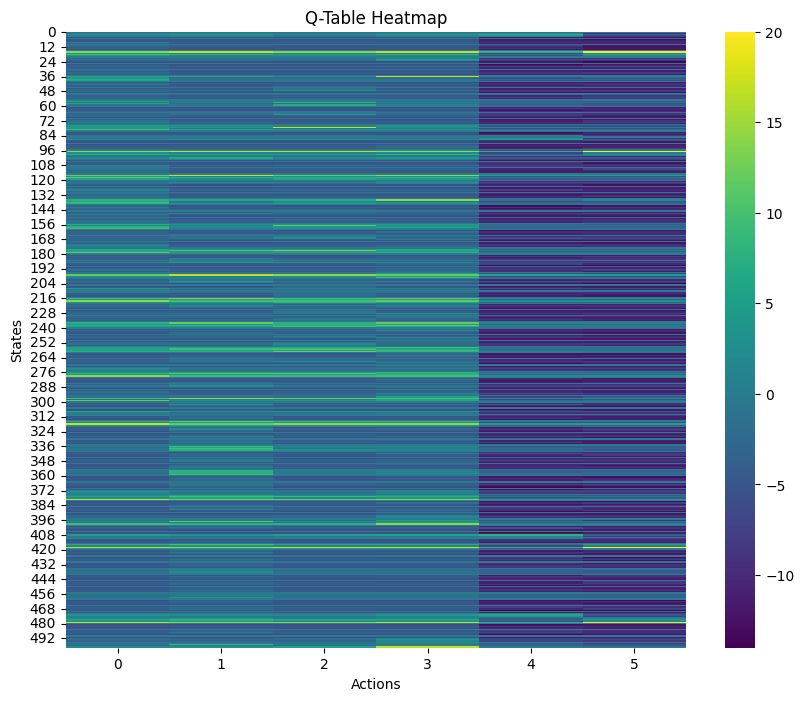

In [22]:
plt.figure(figsize=(10,8))
sns.heatmap(agent.Q, cmap="viridis")
plt.title("Q-Table Heatmap")
plt.xlabel("Actions")
plt.ylabel("States")
plt.show()

# Policy visualization

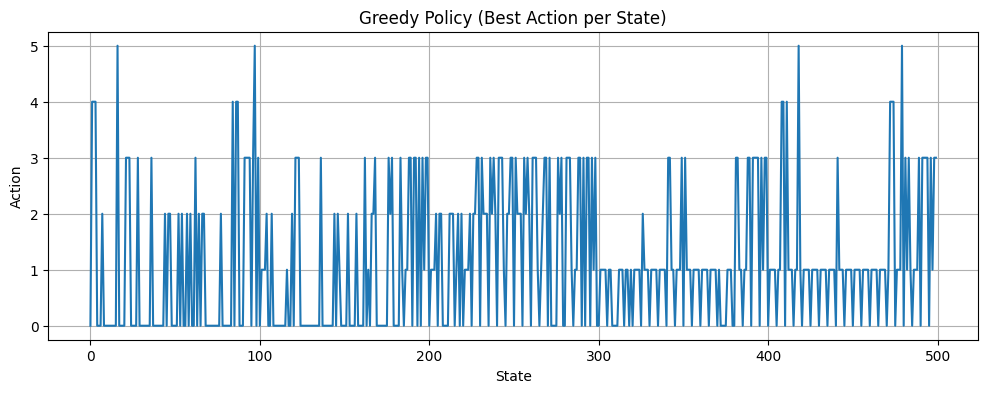

In [23]:
policy = np.argmax(agent.Q, axis=1)

plt.figure(figsize=(12,4))
plt.plot(policy)
plt.title("Greedy Policy (Best Action per State)")
plt.xlabel("State")
plt.ylabel("Action")
plt.grid(True)
plt.show()

# Run Taxi

In [24]:
#main()